# GRN Accuracy Evaluations with TF binding Database Cistrome

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
from numba.core.errors import NumbaDeprecationWarning
warnings.simplefilter("ignore", category=NumbaDeprecationWarning)
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

In [3]:
import os
import sys
import numpy as np
import pandas as pd

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
sys.path.append("/home/chenxufeng/WorkSpace/scMagnify/src/")
from grn_tools import GRNEvaluator, GROUNDTRUTHS_TISSUE, METHOD_PALETTE_CISTROME, DIRPJTHOMES, METHOD_ORDER_CISTROME, show_color_dict

## Configurations

In [6]:
%matplotlib inline
plt.rcParams["figure.figsize"] = (5, 5)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "Arial"
plt.rcParams["image.cmap"] = "Spectral_r"

# For saving vector graphics
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["text.usetex"] = False

In [7]:
fig_dir = "../figures/Fig2/" 
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
data_dir = "../data/Fig2/"
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

In [8]:
trail_id = "250423"

t_cell_home = DIRPJTHOMES["PMID36973557_NatBiotechnol2023_T-cell-depleted"]
cd34_home = DIRPJTHOMES["PMID36973557_NatBiotechnol2023_CD34"]

t_cell_net = f"{t_cell_home}/benchmark/{trail_id}/net/"
cd34_net = f"{cd34_home}/benchmark/{trail_id}/net/"

## GRNEvaluator

In [9]:
geval = GRNEvaluator()

In [10]:
geval.load_groundtruths(GROUNDTRUTHS_TISSUE)

Output()

✅Load complete. Successfully added 13 ground truth networks.

### Basic Settings

In [11]:
algos = ["Dictys", "FigR", "Pando", "CellOracle", "SCENIC", "Velorama", "GRNBoost2", "SINCERITIES", "LINGER", "scMagnify"]
regex_pattern = "|".join(algos)

In [12]:
regex_pattern

'Dictys|FigR|Pando|CellOracle|SCENIC|Velorama|GRNBoost2|SINCERITIES|LINGER|scMagnify'

In [13]:
import scmagnify as scm
scm_dir = os.path.dirname(scm.__file__)
human_tf_file = os.path.join(scm_dir, "data", "tf_lists", f"allTFs_hg38.txt")
tf_list = pd.read_csv(human_tf_file, header=None)[0].tolist()

tcell_gene_list = pd.read_csv(f"{t_cell_home}/benchmark/gene_list/test_assoc_fdr1e-3_A0.3.csv", header=None)[0].tolist()
cd34_gene_list = pd.read_csv(f"{cd34_home}/benchmark/gene_list/test_assoc_fdr1e-3_A0.3.csv", header=None)[0].tolist()

{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

<Figure size 600x450 with 0 Axes>

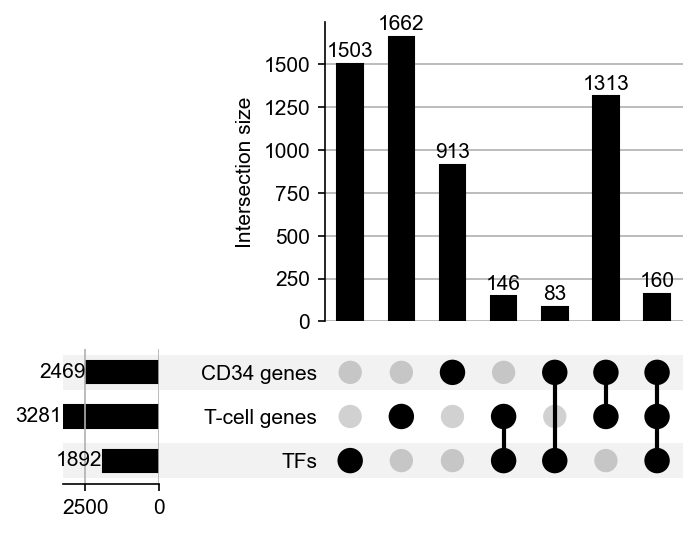

In [14]:
from upsetplot import UpSet, from_contents

# tf_list tcell_gene_list cd34_gene_list
contents = {
    "TFs": set(tf_list),
    "T-cell genes": set(tcell_gene_list),
    "CD34 genes": set(cd34_gene_list)
}

upset_data = from_contents(contents)
plt.figure(figsize=(4, 3))
upset = UpSet(upset_data, subset_size='count', show_counts='%d', sort_by='degree', sort_categories_by=None)
upset.plot()

### Load GRN Networks

In [15]:
geval.load_grns(t_cell_net, 
                dataset="PMID36973557_NatBiotechnol2023_T-cell-depleted",
                regex=regex_pattern,
                tf_filter=list(set(tf_list) & set(tcell_gene_list)))

🔍 Regex filter 'Dictys|FigR|Pando|CellOracle|SCENIC|Velorama|GRNBoost2|SINCERITIES|LINGER|scMagnify' matched 33 
out of 72 files.

Output()

✅Scan complete. Loaded 33 networks from 
'/home/chenxufeng/picb_cxf/Data/PMID36973557_NatBiotechnol2023_T-cell-depleted//benchmark/250423/net/'.

In [16]:
geval.load_grns(cd34_net, 
                dataset="PMID36973557_NatBiotechnol2023_CD34",
                regex=regex_pattern, 
                tf_filter=list(set(tf_list) & set(cd34_gene_list)))

🔍 Regex filter 'Dictys|FigR|Pando|CellOracle|SCENIC|Velorama|GRNBoost2|SINCERITIES|LINGER|scMagnify' matched 66 
out of 144 files.

Output()

✅Scan complete. Loaded 66 networks from 
'/home/chenxufeng/picb_cxf/Data/PMID36973557_NatBiotechnol2023_CD34//benchmark/250423/net/'.

In [17]:
geval.describe_networks(sort_by = "Algorithm")

                                         Predicted Network Descriptions                                          
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━┳━━━━━━━━━┓
┃ Algorithm         ┃ Dataset                                        ┃ Lineage ┃  Edges ┃ Nodes ┃ TFs ┃ Targets ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━╇━━━━━━━━━┩
│ CellOracle        │ PMID36973557_NatBiotechnol2023_T-cell-depleted │ Mono    │  60030 │  2999 │ 153 │    2992 │
│ CellOracle        │ PMID36973557_NatBiotechnol2023_T-cell-depleted │ Ery     │  60030 │  2999 │ 153 │    2992 │
│ CellOracle        │ PMID36973557_NatBiotechnol2023_T-cell-depleted │ NaiveB  │  60030 │  2999 │ 153 │    2992 │
│ CellOracle        │ PMID36973557_NatBiotechnol2023_CD34            │ Mono    │  31060 │  2355 │ 111 │    2348 │
│ CellOracle        │ PMID36973557_NatBiotechnol2023_CD34            │ CLP     │  31060 │  2355 │ 111 │    2348 │
│ CellOracle        │ PMID36973557_NatBiotechnol2023_CD34            │ Ery     │  31060 │  2355 │ 111 │    2348 │
│ CellOracle        │ PMID36973557_NatBiotechnol2023_CD34            │ cDC     │  31060 │  2355 │ 111 │    2348 │
│ CellOracle        │ PMID36973557_NatBiotechnol2023_CD34            │ Mega    │  31060 │  2355 │ 111 │    2348 │
│ CellOracle        │ PMID36973557_NatBiotechnol2023_CD34            │ pDC     │  31060 │  2355 │ 111 │    2348 │
│ Dictys            │ PMID36973557_NatBiotechnol2023_T-cell-depleted │ Mono    │  59120 │  3037 │  98 │    3033 │
│ Dictys            │ PMID36973557_NatBiotechnol2023_T-cell-depleted │ Ery     │  54218 │  2810 │  91 │    2809 │
│ Dictys            │ PMID36973557_NatBiotechnol2023_T-cell-depleted │ NaiveB  │  56824 │  2922 │  95 │    2921 │
│ Dictys            │ PMID36973557_NatBiotechnol2023_CD34            │ Mono    │  46137 │  2382 │  61 │    2382 │
│ Dictys            │ PMID36973557_NatBiotechnol2023_CD34            │ CLP     │  46249 │  2390 │  61 │    2390 │
│ Dictys            │ PMID36973557_NatBiotechnol2023_CD34            │ Ery     │  44831 │  2324 │  60 │    2324 │
│ Dictys            │ PMID36973557_NatBiotechnol2023_CD34            │ cDC     │  46636 │  2407 │  64 │    2407 │
│ Dictys            │ PMID36973557_NatBiotechnol2023_CD34            │ Mega    │  43249 │  2239 │  60 │    2239 │
│ Dictys            │ PMID36973557_NatBiotechnol2023_CD34            │ pDC     │  46799 │  2416 │  64 │    2416 │
│ FigR              │ PMID36973557_NatBiotechnol2023_T-cell-depleted │ Ery     │ 297325 │  1772 │ 175 │    1699 │
│ FigR              │ PMID36973557_NatBiotechnol2023_T-cell-depleted │ Mono    │ 330050 │  1933 │ 175 │    1886 │
│ FigR              │ PMID36973557_NatBiotechnol2023_T-cell-depleted │ NaiveB  │ 315525 │  1858 │ 175 │    1803 │
│ FigR              │ PMID36973557_NatBiotechnol2023_CD34            │ pDC     │ 173535 │  1543 │ 115 │    1509 │
│ FigR              │ PMID36973557_NatBiotechnol2023_CD34            │ Mega    │ 163476 │  1471 │ 114 │    1434 │
│ FigR              │ PMID36973557_NatBiotechnol2023_CD34            │ Ery     │ 169050 │  1508 │ 115 │    1470 │
│ FigR              │ PMID36973557_NatBiotechnol2023_CD34            │ cDC     │ 172730 │  1544 │ 115 │    1502 │
│ FigR              │ PMID36973557_NatBiotechnol2023_CD34            │ Mono    │ 167670 │  1492 │ 115 │    1458 │
│ FigR              │ PMID36973557_NatBiotechnol2023_CD34            │ CLP     │ 168475 │  1502 │ 115 │    1465 │
│ GRNBoost2         │ PMID36973557_NatBiotechnol2023_T-cell-depleted │ Mono    │ 262013 │  3281 │ 306 │    3281 │
│ GRNBoost2         │ PMID36973557_NatBiotechnol2023_T-cell-depleted │ Ery     │ 280021 │  3281 │ 306 │    3281 │
│ GRNBoost2         │ PMID36973557_NatBiotechnol2023_T-cell-depleted │ NaiveB  │ 285732 │  3280 │ 306 │    3280 │
│ GRNBoost2         │ PMID36973557_NatBiotechnol2023_CD34            │ Mono    │ 195853 │  2469 │ 243 │    2469 │
│ GRNBoost

In [19]:
geval.calculate_accuracy()

Output()

,Algorithm,Dataset,Lineage,AUPR,AUPR Ratio,AUROC,EPR,F1 Score (topk),F0.1 Score (topk),threshold
0,CellOracle,PMID36973557_NatBiotechnol2023_T-cell-depleted,Mono,0.159021,1.057673,0.527220,1.284914,0.193243,0.193247,0.001013
1,Pando,PMID36973557_NatBiotechnol2023_T-cell-depleted,Ery,0.154473,1.061486,0.520831,0.815312,0.175509,0.185076,0.000002
2,SINCERITIES,PMID36973557_NatBiotechnol2023_T-cell-depleted,Mono,0.145270,0.983864,0.489789,0.958573,0.141596,0.141596,0.000280
3,Dictys,PMID36973557_NatBiotechnol2023_T-cell-depleted,Mono,0.158719,1.002039,0.499134,0.892979,0.148643,0.156407,0.000006
4,CellOracle,PMID36973557_NatBiotechnol2023_T-cell-depleted,Ery,0.160858,1.069895,0.527528,1.288637,0.193803,0.193807,0.001700
...,...,...,...,...,...,...,...,...,...,...
94,scMagnify,PMID36973557_NatBiotechnol2023_CD34,Mono,0.196650,1.110834,0.543872,1.160995,0.205635,0.205642,0.000005
95,scMagnify,PMID36973557_NatBiotechnol2023_CD34,Ery,0.197231,1.113453,0.537849,1.193785,0.211473,0.211488,0.000637
96,scMagnify,PMID36973557_NatBiotechnol2023_CD34,cDC,0.199557,1.136217,0.546846,1.180482,0.207341,0.207355,0.000205
97,scMagnify-nobasal,PMID36973557_NatBiotechnol2023_CD34,pDC,0.159359,1.013496,0.505017,1.013650,0.159390,0.159398,0.044034


Generating scatter plot for 'AUPR' vs 'F1 Score (topk)'...

{'CellOracle': '#1f77b4', 'Pando': '#9471C9', 'SINCERITIES': '#17becf', 'Dictys': '#e377c2', 'SCENIC': '#d62728', 'scMagnify-nobasal': '#F6AE2D', 'GRNBoost2': '#CC7061', 'Velorama': '#8BBEB2', 'LINGER': '#8c564b', 'FigR': '#2ca02c', 'scMagnify': '#ff7f0e'}


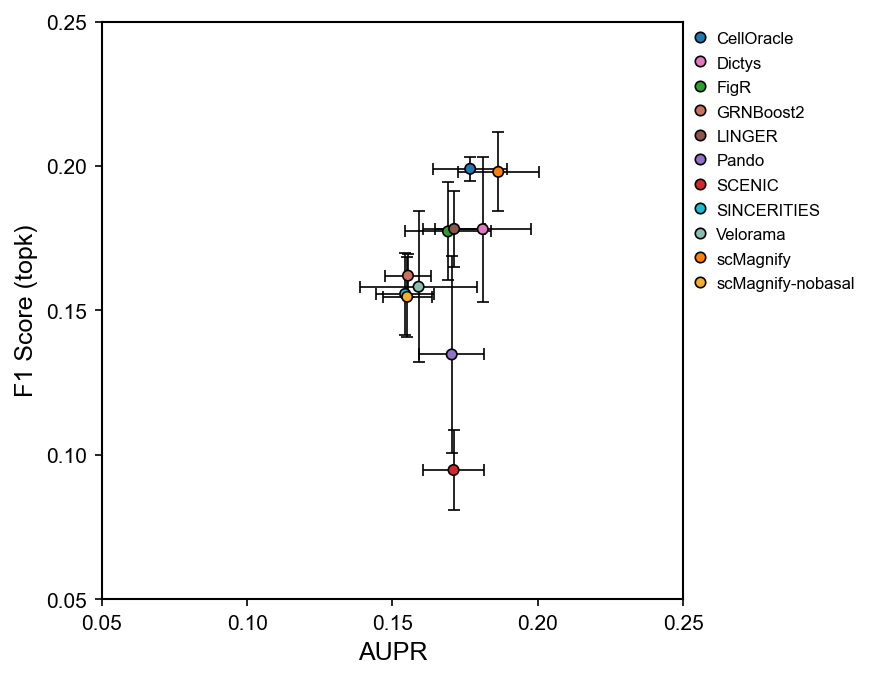

In [20]:
geval.plot_scatter(
    x_metric="AUPR",
    y_metric="F1 Score (topk)",
    xlim=[0.05, 0.25],
    ylim=[0.05, 0.25],
    regex={"Algorithm": regex_pattern},
    
)

In [21]:
METHOD_ORDER_CISTROME = [
    "scMagnify", 
    "scMagnify-nobasal", 
    "LINGER",
    "Dictys", 
    "CellOracle", 
    "FigR", 
    "Pando",
    "SCENIC", 
    "Velorama",
    "SINCERITIES",
    "GRNBoost2",
]

In [22]:
geval.accuracy_results['Algorithm'] = pd.Categorical(
    geval.accuracy_results['Algorithm'],
    categories=METHOD_ORDER_CISTROME,
    ordered=True
)

geval.accuracy_results = geval.accuracy_results.sort_values(by="Algorithm")

In [23]:
geval.accuracy_results.head()

,Algorithm,Dataset,Lineage,AUPR,AUPR Ratio,AUROC,EPR,F1 Score (topk),F0.1 Score (topk),threshold
82,scMagnify,PMID36973557_NatBiotechnol2023_CD34,CLP,0.194584,1.108022,0.543531,1.163280,0.204367,0.204381,0.000006
96,scMagnify,PMID36973557_NatBiotechnol2023_CD34,cDC,0.199557,1.136217,0.546846,1.180482,0.207341,0.207355,0.000205
95,scMagnify,PMID36973557_NatBiotechnol2023_CD34,Ery,0.197231,1.113453,0.537849,1.193785,0.211473,0.211488,0.000637
51,scMagnify,PMID36973557_NatBiotechnol2023_CD34,pDC,0.193418,1.103227,0.541777,1.143200,0.200573,0.200587,0.000052
94,scMagnify,PMID36973557_NatBiotechnol2023_CD34,Mono,0.196650,1.110834,0.543872,1.160995,0.205635,0.205642,0.000005


## Visualization 

Generating scatter plot for 'AUPR' vs 'F1 Score (topk)'...

{'scMagnify': '#ff7f0e', 'scMagnify-nobasal': '#F6AE2D', 'LINGER': '#8c564b', 'Dictys': '#e377c2', 'CellOracle': '#1f77b4', 'FigR': '#2ca02c', 'Pando': '#9471C9', 'SCENIC': '#d62728', 'Velorama': '#8BBEB2', 'SINCERITIES': '#17becf', 'GRNBoost2': '#CC7061'}


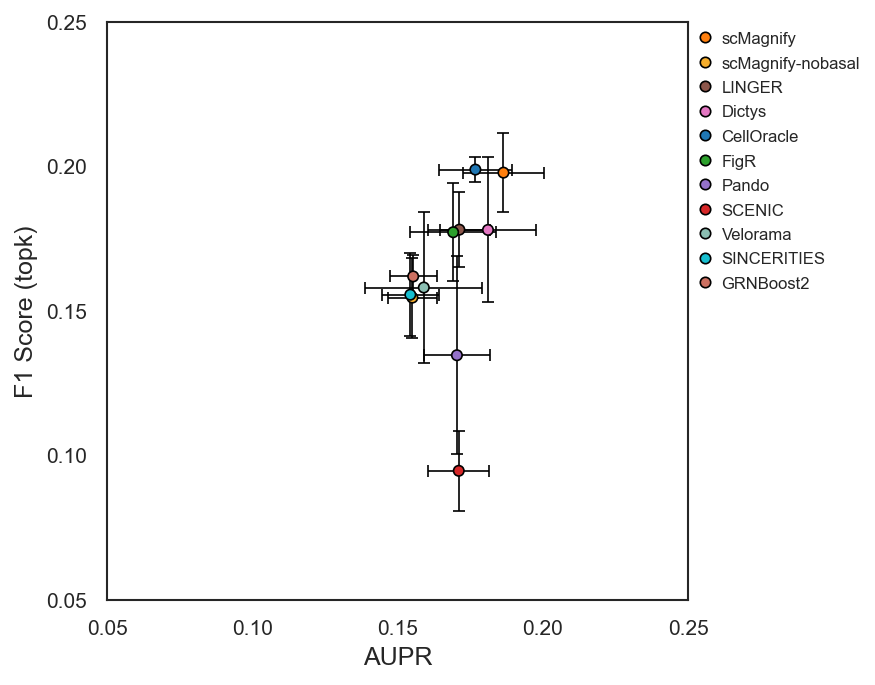

In [24]:
sns.set(style="white")
with plt.rc_context({'figure.dpi': 150, 'savefig.dpi': 300, 'figure.figsize': (5,5)}):
    geval.plot_scatter(
        x_metric="AUPR",
        y_metric="F1 Score (topk)",
        xlim=[0.05, 0.25],
        ylim=[0.05, 0.25],
        regex={"Algorithm": regex_pattern},
    )

Generating scatter plot for 'AUPR' vs 'F0.1 Score (topk)'...

{'scMagnify': '#ff7f0e', 'scMagnify-nobasal': '#F6AE2D', 'LINGER': '#8c564b', 'Dictys': '#e377c2', 'CellOracle': '#1f77b4', 'FigR': '#2ca02c', 'Pando': '#9471C9', 'SCENIC': '#d62728', 'Velorama': '#8BBEB2', 'SINCERITIES': '#17becf', 'GRNBoost2': '#CC7061'}


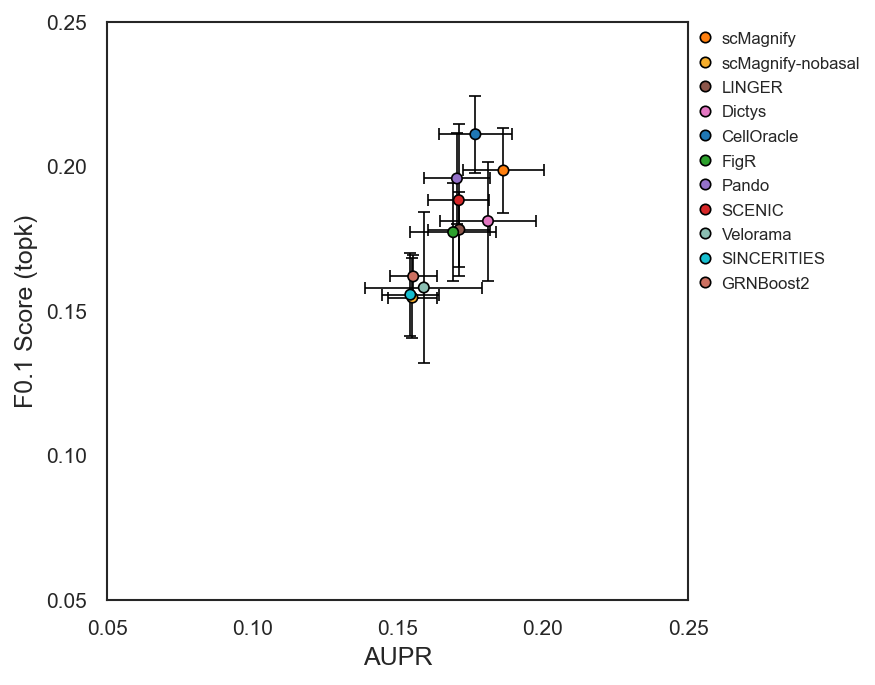

In [25]:
with plt.rc_context({'figure.dpi': 150, 'savefig.dpi': 300, 'figure.figsize': (5,5)}):
    geval.plot_scatter(
        x_metric="AUPR",
        y_metric="F0.1 Score (topk)",
        xlim=[0.05, 0.25],
        ylim=[0.05, 0.25],
        regex={"Algorithm": regex_pattern},
    )

['scMagnify', 'scMagnify-nobasal', 'LINGER', 'Dictys', 'CellOracle', 'FigR', 'Pando', 'SCENIC', 'Velorama', 'SINCERITIES', 'GRNBoost2']


2025-10-09 12:49:24 | [INFO] maxp pruned
2025-10-09 12:49:24 | [INFO] LTSH dropped
2025-10-09 12:49:24 | [INFO] cmap pruned
2025-10-09 12:49:24 | [INFO] kern pruned
2025-10-09 12:49:24 | [INFO] post pruned
2025-10-09 12:49:24 | [INFO] PCLT dropped
2025-10-09 12:49:24 | [INFO] DSIG dropped
2025-10-09 12:49:24 | [INFO] glyf pruned
2025-10-09 12:49:24 | [INFO] Added gid0 to subset
2025-10-09 12:49:24 | [INFO] Added first four glyphs to subset
2025-10-09 12:49:24 | [INFO] Closing glyph list over 'glyf': 51 glyphs before
2025-10-09 12:49:24 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'a', 'b', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'six', 'space', 't', 'two', 'y', 'zero']
2025-10-09 12:49:24 | [INFO] Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 17, 19, 20, 21, 23, 24, 25, 27, 36, 37

💾 Saved combined accuracy plot to: ../figures/Fig2/Fig2c-tf_binding_accuracy_scatter_AUPR_F1.pdf

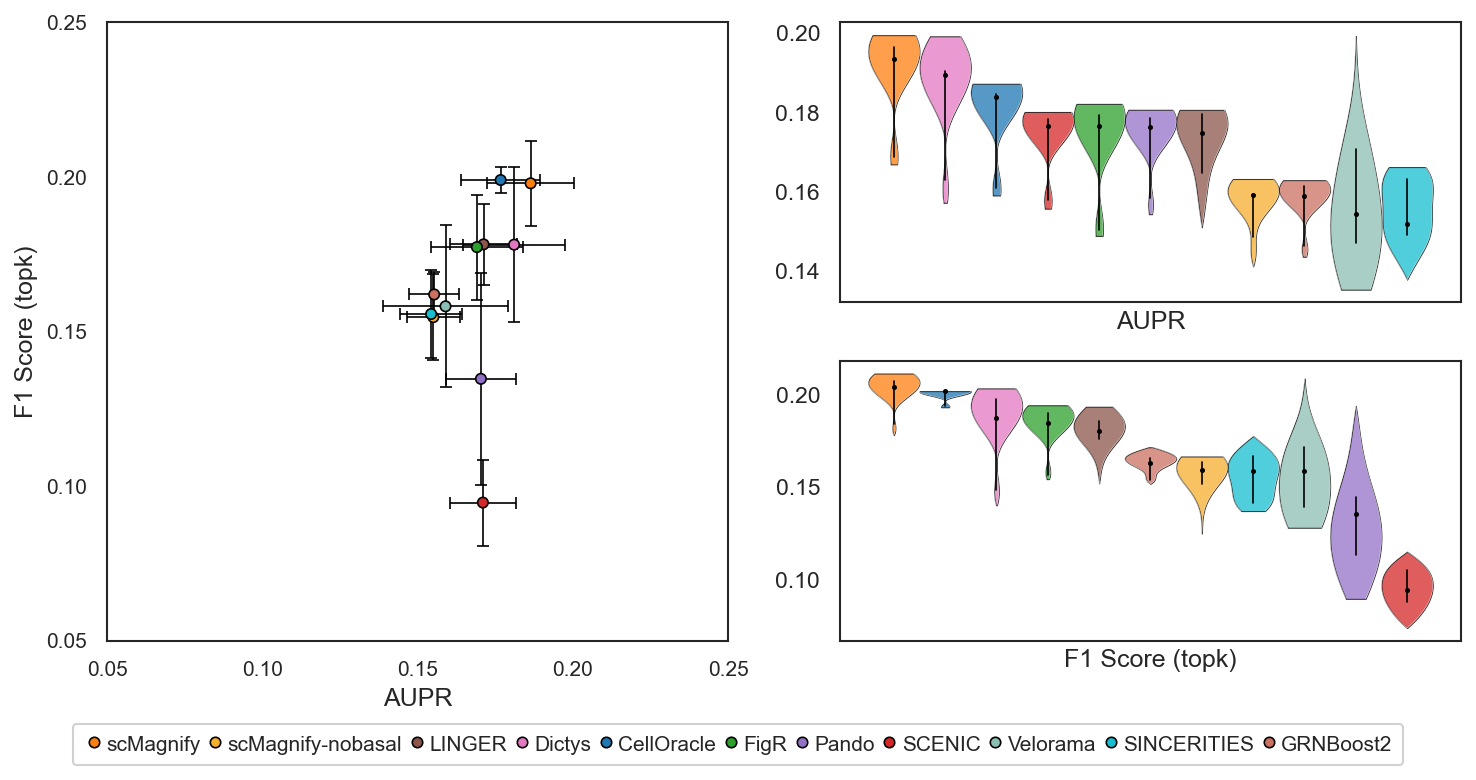

In [26]:
plt.rcParams["figure.figsize"] = (5,5)
geval.plot_acc(
    x_metric="AUPR",
    y_metric="F1 Score (topk)",
    xlim=[0.05, 0.25],
    ylim=[0.05, 0.25],
    save=os.path.join(fig_dir, "Fig2c-tf_binding_accuracy_scatter_AUPR_F1.pdf"),
    regex={"Algorithm": regex_pattern},
)

In [27]:
def plot_barplot(df, metric, lin_list, palette, ax=None, figsize=(15, 4), dpi=300):
    """
    Plot barplot for the given metric.
    
    Parameters:
    -----------
    df: DataFrame
    metric: str
    lin_list: list
    palette: dict
    figsize: tuple
    dpi: int
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    else:
        fig = None

    sns.set_style("ticks")
    sns.barplot(data=df,
                x="x_combined",
                y=metric,
                hue="Algorithm",
                palette=palette,
                ax=ax)
    
    ax.set_ylabel(metric)
    ax.set_xlabel(None)
    ax.set_xticklabels(lin_list)
    algo_list = df["Algorithm"].unique().tolist()   
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=len(algo_list))
    
    return ax

/var/tmp/ipykernel_3025098/3084695658.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(lin_list)
/var/tmp/ipykernel_3025098/3084695658.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(lin_list)
2025-10-09 12:49:55 | [INFO] maxp pruned
2025-10-09 12:49:55 | [INFO] LTSH dropped
2025-10-09 12:49:55 | [INFO] cmap pruned
2025-10-09 12:49:55 | [INFO] kern pruned
2025-10-09 12:49:55 | [INFO] post pruned
2025-10-09 12:49:55 | [INFO] PCLT dropped
2025-10-09 12:49:55 | [INFO] DSIG dropped
2025-10-09 12:49:55 | [INFO] glyf pruned
2025-10-09 12:49:55 | [INFO] Added gid0 to subset
2025-10-09 12:49:55 | [INFO] Added first four glyphs to subset
2025-10-09 12:49:55 | [INFO] Closing glyph list over 'glyf': 50 glyphs before
2025-10-09 12:49:55 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B

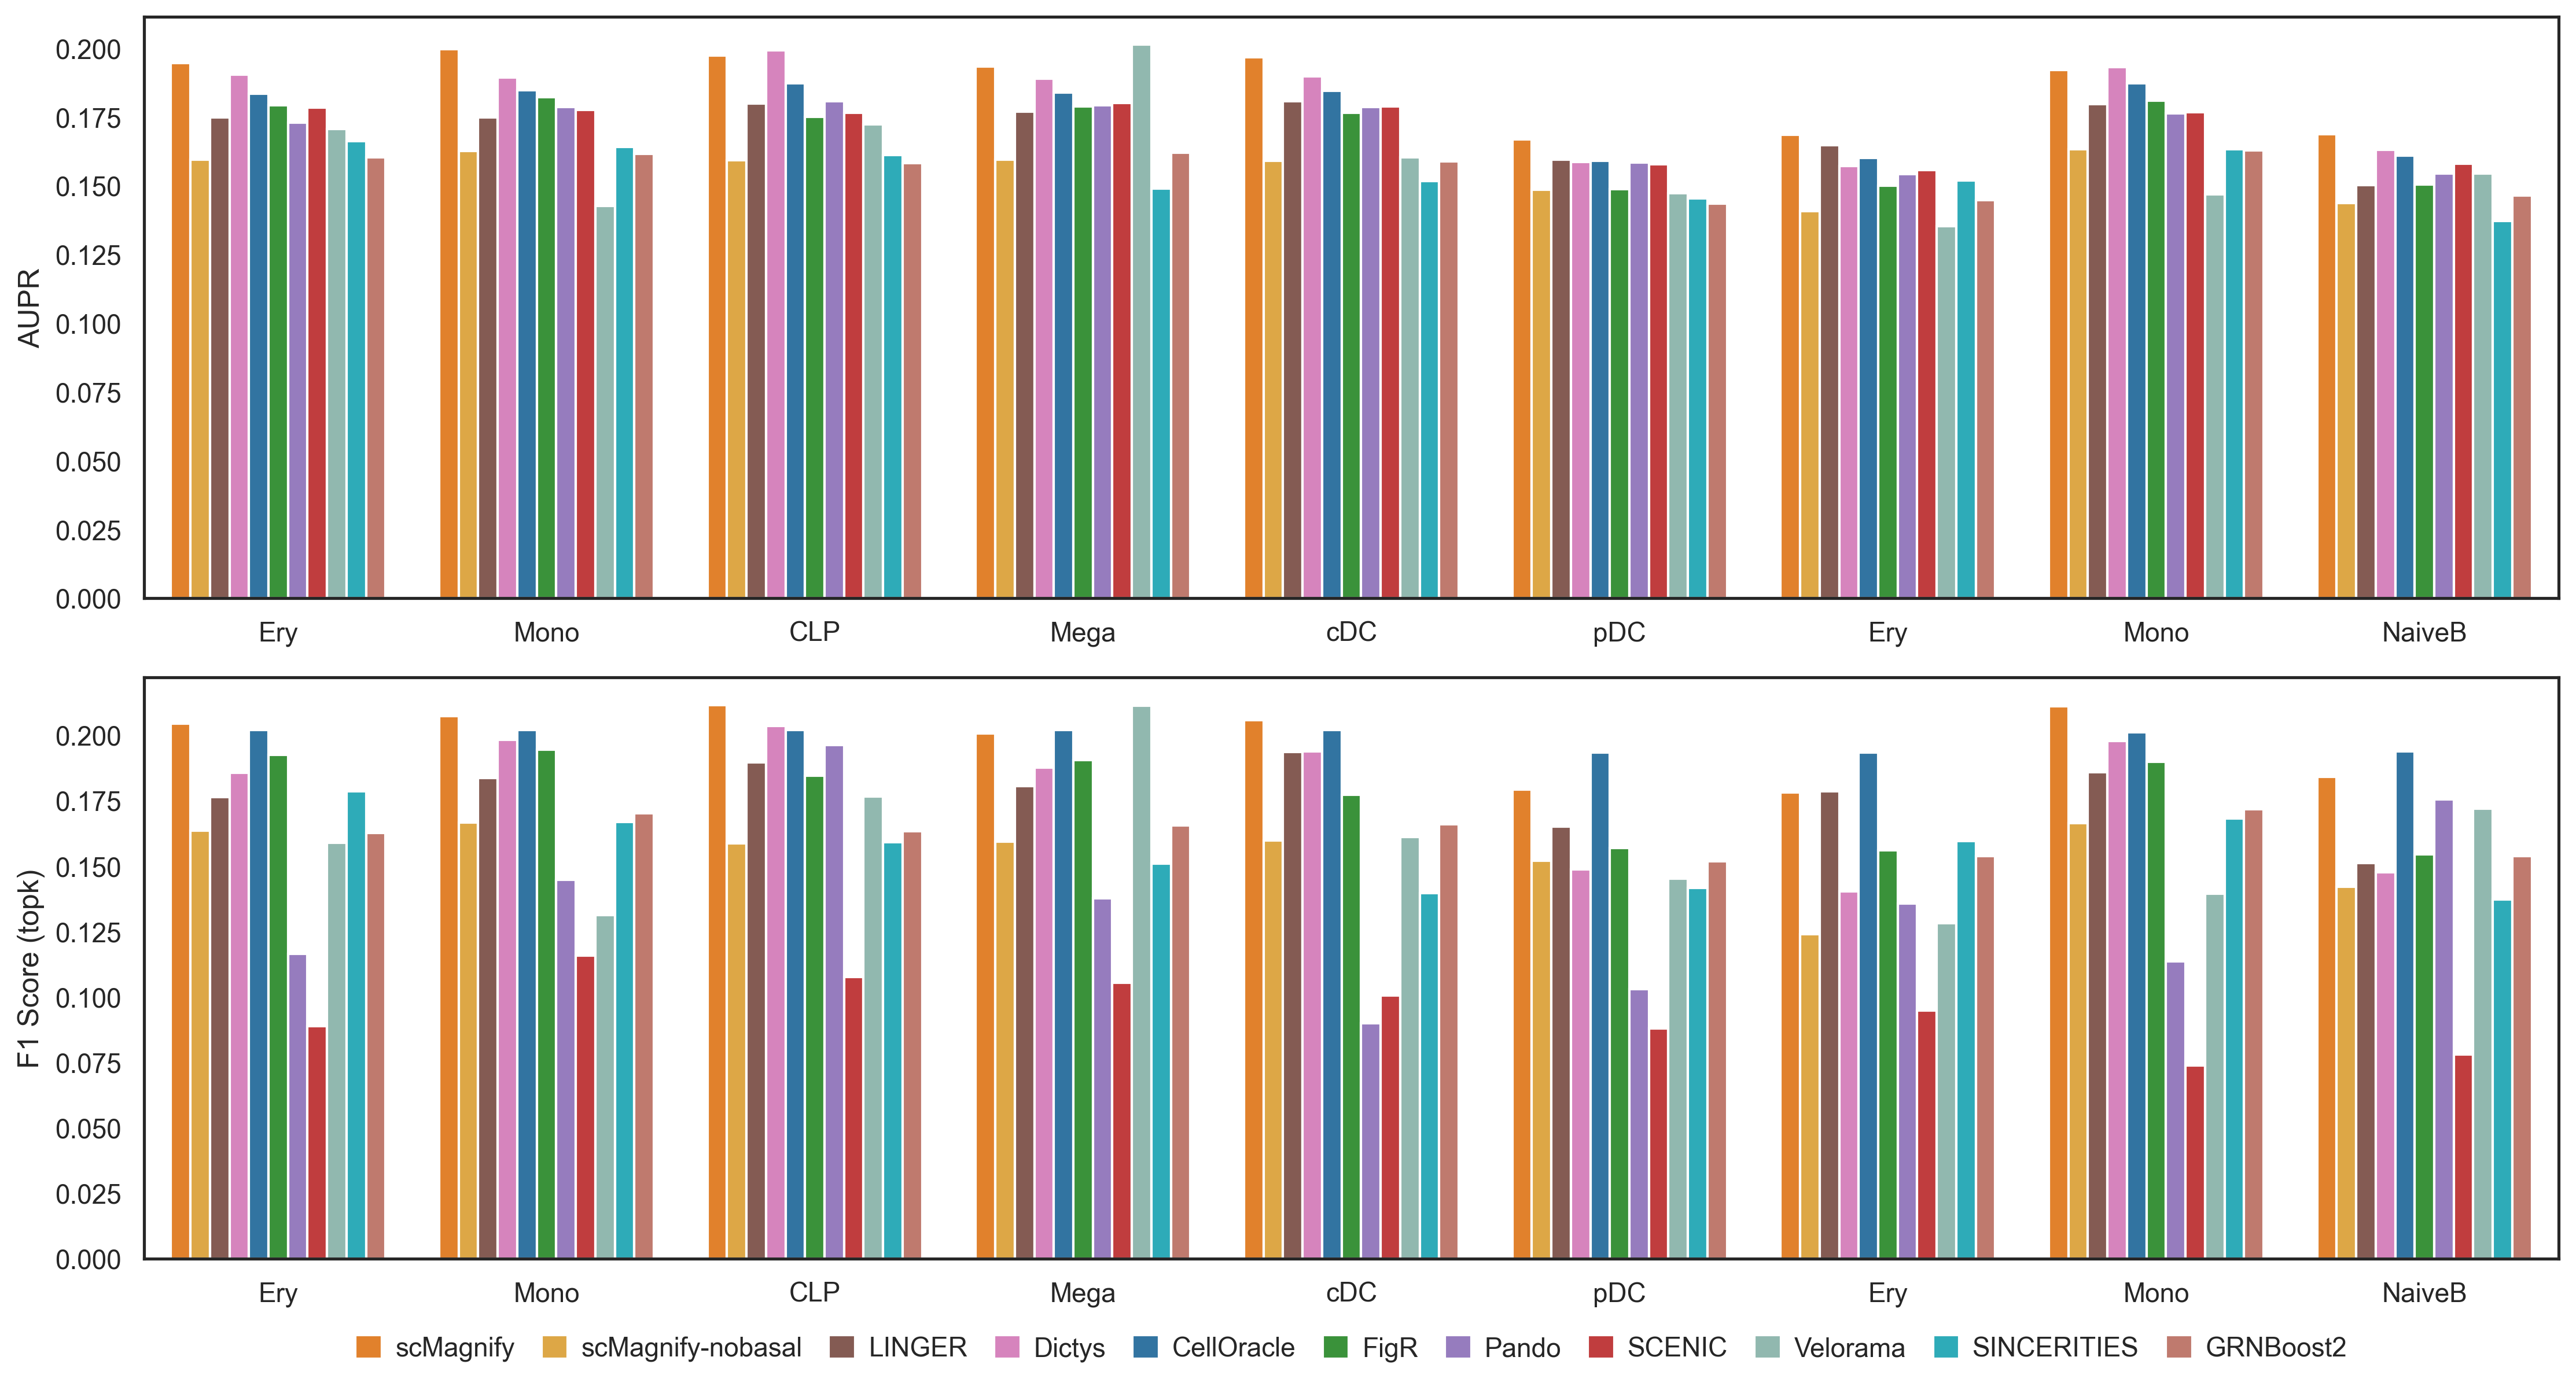

In [28]:
lin_list = ["Ery", "Mono", "CLP", "Mega", "cDC", "pDC", "Ery", "Mono", "NaiveB"]
algo_list = geval.accuracy_results["Algorithm"].unique().tolist()
df = geval.accuracy_results.copy()
df["x_combined"] = df["Lineage"] + "\n" + df["Dataset"]
metrics_list = ["AUPR", "F1 Score (topk)"]

fig, axes = plt.subplots(2, 1, figsize=(15, 8), dpi=300)
axes = axes.flatten()

for i, metric in enumerate(metrics_list):
    plot_barplot(df, metric, lin_list, METHOD_PALETTE_CISTROME, ax=axes[i])

axes[0].get_legend().remove()
fig.tight_layout()

fig.savefig(os.path.join(fig_dir, "SupFig3ab-tf_binding_accuracy_barplot_AUPR_F1.pdf"), bbox_inches='tight')

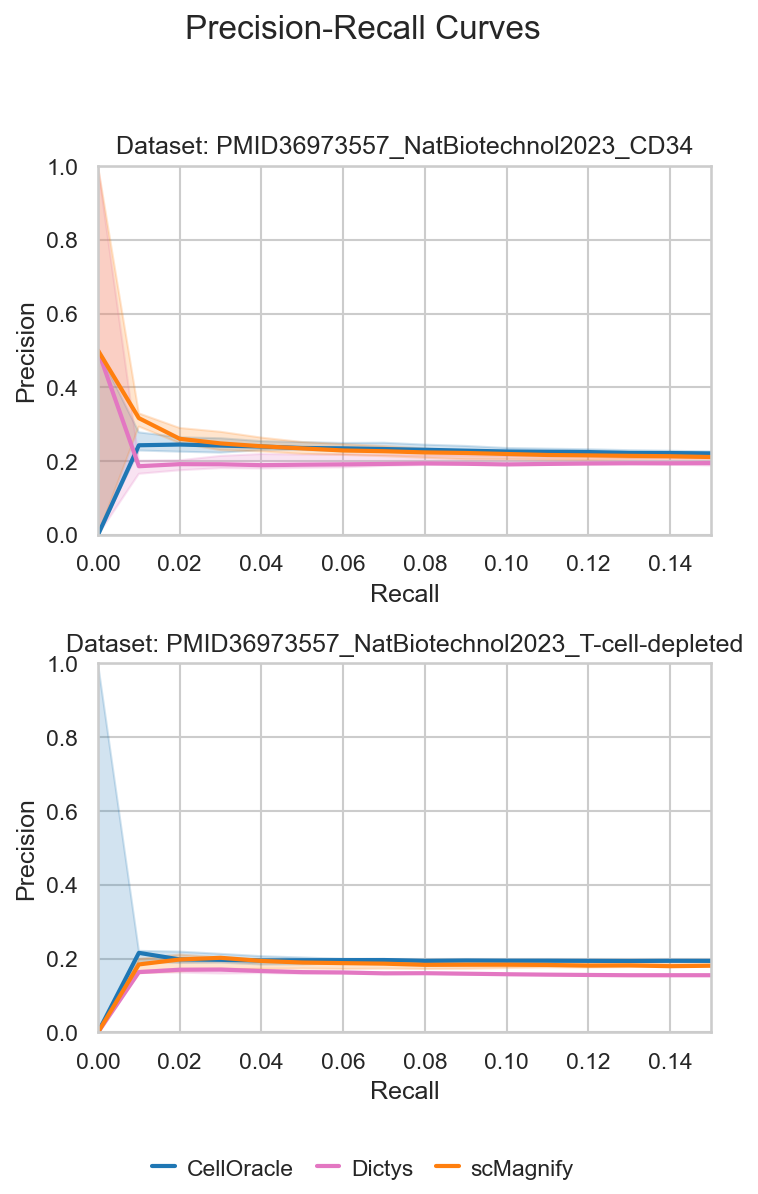

2025-10-09 13:05:45 | [INFO] maxp pruned
2025-10-09 13:05:45 | [INFO] LTSH dropped
2025-10-09 13:05:45 | [INFO] cmap pruned
2025-10-09 13:05:45 | [INFO] kern pruned
2025-10-09 13:05:45 | [INFO] post pruned
2025-10-09 13:05:45 | [INFO] PCLT dropped
2025-10-09 13:05:45 | [INFO] DSIG dropped
2025-10-09 13:05:45 | [INFO] glyf pruned
2025-10-09 13:05:45 | [INFO] Added gid0 to subset
2025-10-09 13:05:45 | [INFO] Added first four glyphs to subset
2025-10-09 13:05:45 | [INFO] Closing glyph list over 'glyf': 46 glyphs before
2025-10-09 13:05:45 | [INFO] Glyph names: ['.notdef', '.null', 'B', 'C', 'D', 'I', 'M', 'N', 'O', 'P', 'R', 'T', 'a', 'c', 'colon', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'l', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'underscore', 'v', 'y', 'zero']
2025-10-09 13:05:45 | [INFO] Glyph IDs:   [0, 1, 2, 3, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 37, 38, 39, 44, 

💾 Saved performance curves to: ../figures/Fig2/Fig2d-tf_binding_accuracy_pr_curve.pdf

In [29]:
geval.plot_performance_curves(
    curve_type = "pr",
    group_by="Dataset",
    xlim=[0, 0.15],
    ylim=[0, 1.00],
    ncols=1,
    query="Algorithm == 'scMagnify' or Algorithm == 'Dictys' or Algorithm == 'CellOracle'",
    save=os.path.join(fig_dir, "Fig2d-tf_binding_accuracy_pr_curve.pdf")
)

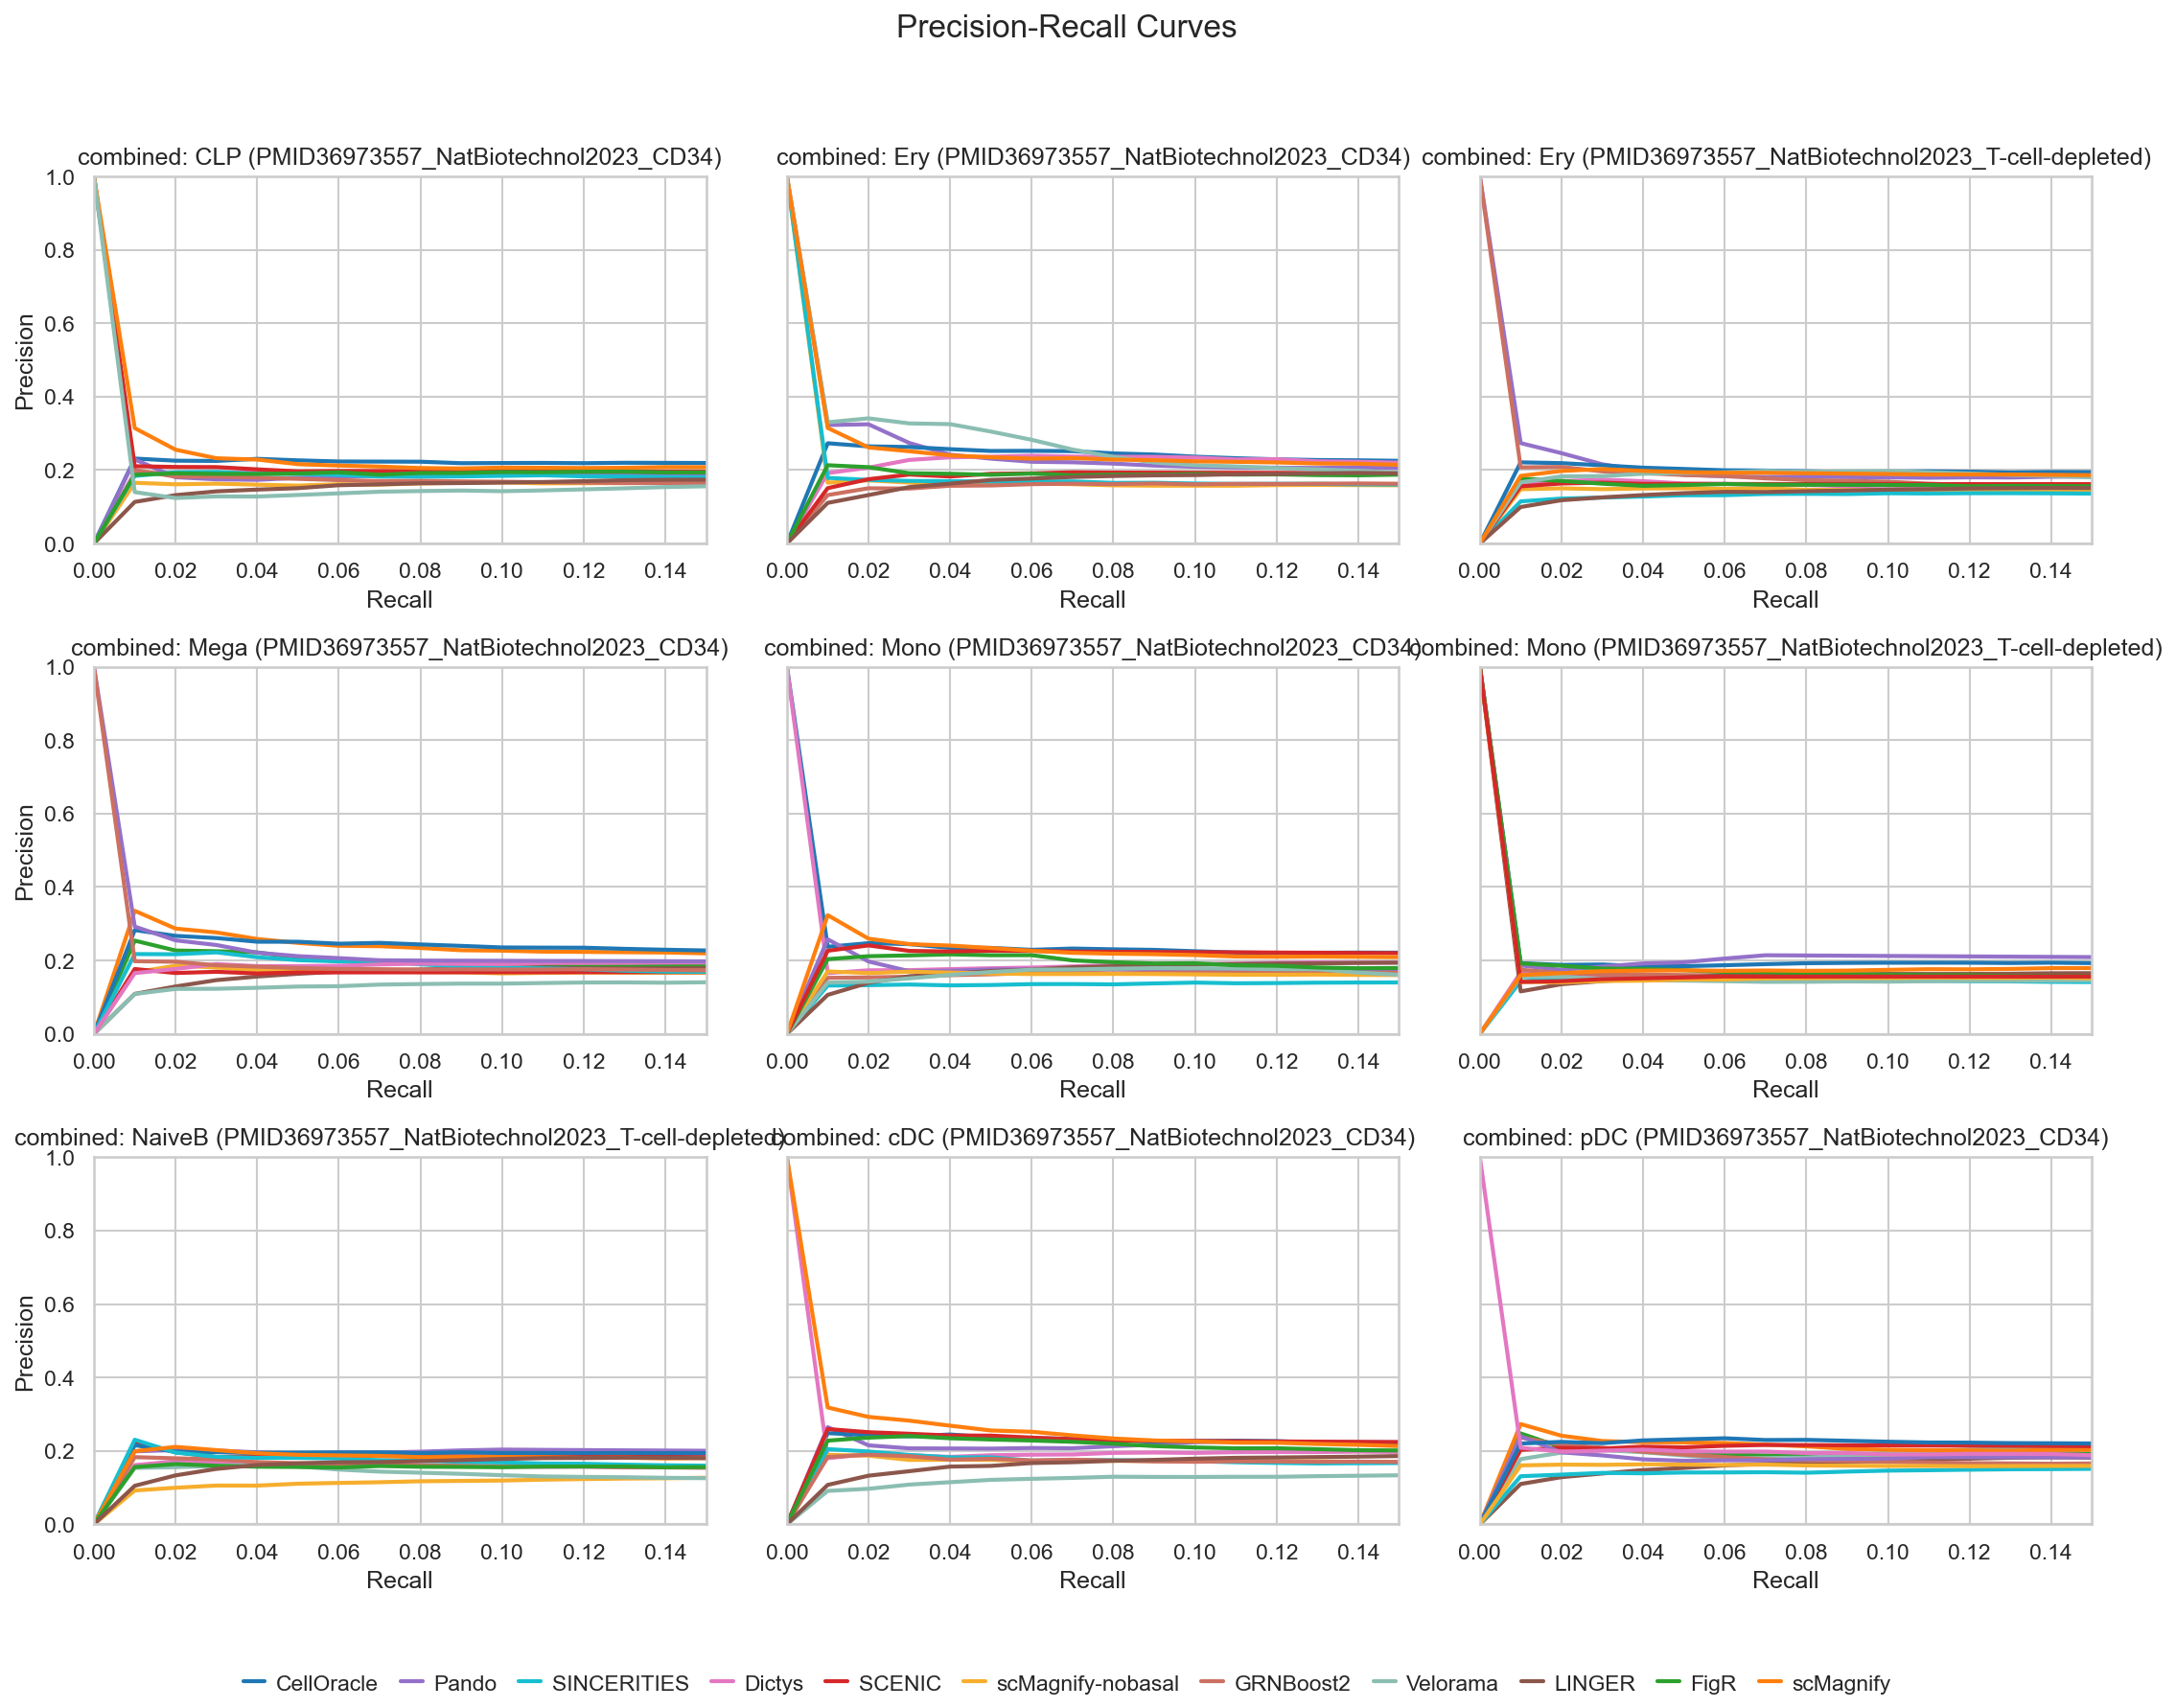

2025-10-09 13:05:52 | [INFO] maxp pruned
2025-10-09 13:05:52 | [INFO] LTSH dropped
2025-10-09 13:05:52 | [INFO] cmap pruned
2025-10-09 13:05:52 | [INFO] kern pruned
2025-10-09 13:05:52 | [INFO] post pruned
2025-10-09 13:05:52 | [INFO] PCLT dropped
2025-10-09 13:05:52 | [INFO] DSIG dropped
2025-10-09 13:05:52 | [INFO] glyf pruned
2025-10-09 13:05:52 | [INFO] Added gid0 to subset
2025-10-09 13:05:52 | [INFO] Added first four glyphs to subset
2025-10-09 13:05:52 | [INFO] Closing glyph list over 'glyf': 56 glyphs before
2025-10-09 13:05:52 | [INFO] Glyph names: ['.notdef', '.null', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'V', 'a', 'b', 'c', 'colon', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'underscore', 'v', 'y', 'zero']
2025-10-09 13:05:52 | [INFO] Glyph IDs:   [0, 1, 2, 3, 1

💾 Saved performance curves to: ../figures/Fig2/SupFig3-tf_binding_accuracy_pr_curve_lineage.pdf

In [30]:
geval.plot_performance_curves(
    curve_type = "pr",
    group_by="Lineage",
    xlim=[0, 0.15],
    ylim=[0, 1.00],
    interpolate=True,
    ncols=3,
    query="Algorithm != 'BasalGRN'",
    # query="Algorithm == 'scMagnify' or Algorithm == 'Dictys' or Algorithm == 'CellOracle'",
    save=os.path.join(fig_dir, "SupFig3-tf_binding_accuracy_pr_curve_lineage.pdf")
)

In [32]:
geval.accuracy_results

,Algorithm,Dataset,Lineage,AUPR,AUPR Ratio,AUROC,EPR,F1 Score (topk),F0.1 Score (topk),threshold
82,scMagnify,PMID36973557_NatBiotechnol2023_CD34,CLP,0.194584,1.108022,0.543531,1.163280,0.204367,0.204381,0.000006
96,scMagnify,PMID36973557_NatBiotechnol2023_CD34,cDC,0.199557,1.136217,0.546846,1.180482,0.207341,0.207355,0.000205
95,scMagnify,PMID36973557_NatBiotechnol2023_CD34,Ery,0.197231,1.113453,0.537849,1.193785,0.211473,0.211488,0.000637
51,scMagnify,PMID36973557_NatBiotechnol2023_CD34,pDC,0.193418,1.103227,0.541777,1.143200,0.200573,0.200587,0.000052
94,scMagnify,PMID36973557_NatBiotechnol2023_CD34,Mono,0.196650,1.110834,0.543872,1.160995,0.205635,0.205642,0.000005
...,...,...,...,...,...,...,...,...,...,...
67,GRNBoost2,PMID36973557_NatBiotechnol2023_CD34,Ery,0.158158,1.010900,0.510341,1.043708,0.163301,0.163309,0.153497
81,GRNBoost2,PMID36973557_NatBiotechnol2023_CD34,Mega,0.162898,1.034285,0.508677,1.089580,0.171673,0.171682,0.156589
16,GRNBoost2,PMID36973557_NatBiotechnol2023_T-cell-depleted,Ery,0.146352,1.053833,0.509017,1.106433,0.153701,0.153704,0.165189
55,GRNBoost2,PMID36973557_NatBiotechnol2023_CD34,pDC,0.161889,1.034927,0.505673,1.056986,0.165403,0.165411,0.142926


In [35]:
len(geval.accuracy_details)

99

In [33]:
from typing import List, Dict, Any

def convert_pr_curves_to_dataframe(accuracy_details: List[Dict[str, Any]]) -> pd.DataFrame:
    """
    Converts a list of accuracy results containing PR curves into a summarized DataFrame.

    This function processes a list where each element is a dictionary containing metadata
    and a 'pr_curve' key. It groups the precision values by their corresponding recall
    values for each unique experiment run and calculates the min, median, and max precision.

    Args:
        accuracy_details (List[Dict[str, Any]]): 
            A list of dictionaries, where each dictionary represents an experiment run.
            It must contain a 'meta' dictionary and a 'pr_curve' tuple of (recall_array, precision_array).

    Returns:
        pd.DataFrame: 
            A DataFrame with columns: ['Algorithm', 'Dataset', 'Lineage', 
            'precision_min', 'precision_median', 'precision_max', 'recall'].
    """
    # A list to hold the processed DataFrames for each experiment run.
    processed_data_list = []

    # Iterate over each result dictionary in the input list.
    for result in accuracy_details:
        # Skip if the result doesn't have a valid PR curve.
        if 'pr_curve' not in result or not result['pr_curve'] or len(result['pr_curve'][0]) == 0:
            continue
        
        # Extract metadata and curve data.
        meta = result.get('meta', {})
        recall_vals, precision_vals = result['pr_curve']

        # Create a temporary DataFrame from the raw curve data points.
        temp_df = pd.DataFrame({
            'recall': recall_vals,
            'precision': precision_vals
        })

        # Group by 'recall' and aggregate the 'precision' values.
        # This calculates min, median, and max precision for each unique recall value.
        aggregated_df = temp_df.groupby('recall')['precision'].agg(
            precision_min='min',
            precision_median='median',
            precision_max='max'
        ).reset_index()  # reset_index() turns the 'recall' group keys back into a column.

        # Add the metadata to the aggregated DataFrame.
        # Use .get() to avoid errors if a key is missing.
        aggregated_df['Algorithm'] = meta.get('Algorithm', 'N/A')
        aggregated_df['Dataset'] = meta.get('Dataset', 'N/A')
        aggregated_df['Lineage'] = meta.get('Lineage', 'N/A')

        # Add the processed DataFrame to our list.
        processed_data_list.append(aggregated_df)

    # If no valid data was found, return an empty DataFrame.
    if not processed_data_list:
        return pd.DataFrame(columns=[
            'Algorithm', 'Dataset', 'Lineage', 
            'precision_min', 'precision_median', 'precision_max', 'recall'
        ])

    # Concatenate all individual DataFrames into the final result.
    final_df = pd.concat(processed_data_list, ignore_index=True)

    # Reorder columns to match the desired output format.
    column_order = [
        'Algorithm', 'Dataset', 'Lineage',
        'precision_min', 'precision_median', 'precision_max', 'recall'
    ]
    
    return final_df[column_order]

In [37]:
pr_curves_df = convert_pr_curves_to_dataframe(geval.accuracy_details)

In [38]:
pr_curves_df

,Algorithm,Dataset,Lineage,precision_min,precision_median,precision_max,recall
0,CellOracle,PMID36973557_NatBiotechnol2023_T-cell-depleted,Mono,1.000000,1.000000,1.000000,0.000000
1,CellOracle,PMID36973557_NatBiotechnol2023_T-cell-depleted,Mono,0.142857,0.250000,1.000000,0.000043
2,CellOracle,PMID36973557_NatBiotechnol2023_T-cell-depleted,Mono,0.133333,0.174242,0.250000,0.000086
3,CellOracle,PMID36973557_NatBiotechnol2023_T-cell-depleted,Mono,0.142857,0.162281,0.187500,0.000129
4,CellOracle,PMID36973557_NatBiotechnol2023_T-cell-depleted,Mono,0.129032,0.150997,0.181818,0.000172
...,...,...,...,...,...,...,...
700001,Velorama,PMID36973557_NatBiotechnol2023_CD34,CLP,0.193859,0.193900,0.193941,0.999334
700002,Velorama,PMID36973557_NatBiotechnol2023_CD34,CLP,0.193879,0.193882,0.193885,0.999500
700003,Velorama,PMID36973557_NatBiotechnol2023_CD34,CLP,0.193842,0.193874,0.193905,0.999667
700004,Velorama,PMID36973557_NatBiotechnol2023_CD34,CLP,0.193868,0.193868,0.193868,0.999833


## Save the data 

In [39]:
geval.accuracy_results.head()

,Algorithm,Dataset,Lineage,AUPR,AUPR Ratio,AUROC,EPR,F1 Score (topk),F0.1 Score (topk),threshold
82,scMagnify,PMID36973557_NatBiotechnol2023_CD34,CLP,0.194584,1.108022,0.543531,1.163280,0.204367,0.204381,0.000006
96,scMagnify,PMID36973557_NatBiotechnol2023_CD34,cDC,0.199557,1.136217,0.546846,1.180482,0.207341,0.207355,0.000205
95,scMagnify,PMID36973557_NatBiotechnol2023_CD34,Ery,0.197231,1.113453,0.537849,1.193785,0.211473,0.211488,0.000637
51,scMagnify,PMID36973557_NatBiotechnol2023_CD34,pDC,0.193418,1.103227,0.541777,1.143200,0.200573,0.200587,0.000052
94,scMagnify,PMID36973557_NatBiotechnol2023_CD34,Mono,0.196650,1.110834,0.543872,1.160995,0.205635,0.205642,0.000005


In [40]:
geval.accuracy_results.to_csv(os.path.join(data_dir, "Fig2-tf_binding_accuracy_results.csv"), index=False)

In [ ]:
data_to_save = {
    "accuracy_results": geval.accuracy_results,
    "accuracy_details": geval.accuracy_details
}

import pickle
with open(os.path.join(data_dir, "Fig2-tf_binding_accuracy_data.pkl"), "wb") as f:
    pickle.dump(data_to_save, f)

In [41]:
pr_curves_df.to_csv(os.path.join(data_dir, "Fig2-tf_binding_accuracy_pr_curves.csv"), index=False)

In [43]:
output_xlsx = os.path.join(data_dir, "SourceDataFig2cd.xlsx")

with pd.ExcelWriter(output_xlsx, engine='xlsxwriter') as writer:
    geval.accuracy_results[["Algorithm", "Dataset", "Lineage", "AUPR", "F1 Score (topk)"]].to_excel(writer, sheet_name='Fig2c', index=False)
    pr_curves_df.query("Algorithm == 'scMagnify' or Algorithm == 'Dictys' or Algorithm == 'CellOracle'").to_excel(writer, sheet_name='Fig2d', index=False)